# Spam SMS Detection

## Project Objective
The objective of this project is to build an AI model that can classify SMS text messages as either legitimate (ham) or spam. 

Spam detection is a fundamental application of text classification and Natural Language Processing (NLP). As mobile messaging grows, spam messages (such as phishing links, fraudulent promotions, or unsolicited ads) have become a major security and annoyance issue. Automatically filtering these messages requires models that can capture the structural patterns, keyword signatures, and stylistic differences of spam vs. legitimate communication.

In this notebook, we will:
1. **Load and Clean** the UCI SMS Spam Collection dataset.
2. Perform **Exploratory Data Analysis (EDA)** to inspect text lengths and word distributions in spam vs. ham messages.
3. Implement **Text Preprocessing** (cleaning URLs, HTML, punctuation, lowercasing) and extract **TF-IDF features** strictly on training data to prevent leakage.
4. Train and compare three classification algorithms: **Multinomial Naive Bayes**, **Logistic Regression**, and **Support Vector Machine (SVM)**.
5. Evaluate performance using metrics tailored for imbalanced text datasets: **Precision, Recall, F1-Score, and Precision-Recall Area Under the Curve (PR-AUC)**.

## 1. Data Loading & Integrity Checks

Let's load the dataset, drop unnecessary extra columns, and check for missing and duplicate values.

In [1]:
import os
import pandas as pd
import numpy as np

# Locate the dataset file
csv_path = os.path.join("SMS_Spam_Dataset", "spam.csv")
df = pd.read_csv(csv_path, encoding='latin-1')
print(f"Initial dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Clean extra columns and rename remaining
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

# Check for null or missing values
null_values = df.isnull().sum().sum()
print(f"Total missing values: {null_values}")

# Check and handle duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Cleaned dataset shape after removing duplicates: {df.shape[0]} rows")
    
# Map label to binary target
df['target'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

Initial dataset shape: 5572 rows, 5 columns
Total missing values: 0
Number of duplicate rows: 403
Cleaned dataset shape after removing duplicates: 5169 rows


,label,text,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


### Data Integrity Findings
- The dataset contains raw SMS messages with their labels.
- There are **0 missing values** in either the target column or the message text column.
- We identified and dropped **403 duplicate messages** (7.23% of the data) to yield **5,169 unique texts**. Dropping duplicates is crucial in text classification to avoid testing on exact duplicate copies of training sentences, which artificially inflates validation metrics.

## 2. Exploratory Data Analysis (EDA)

Let's explore the distribution of classes and check if message lengths or word counts differ significantly between spam and legitimate messages.

Class Distribution:
Ham (Legitimate): 4516 (87.37%)
Spam: 653 (12.63%)


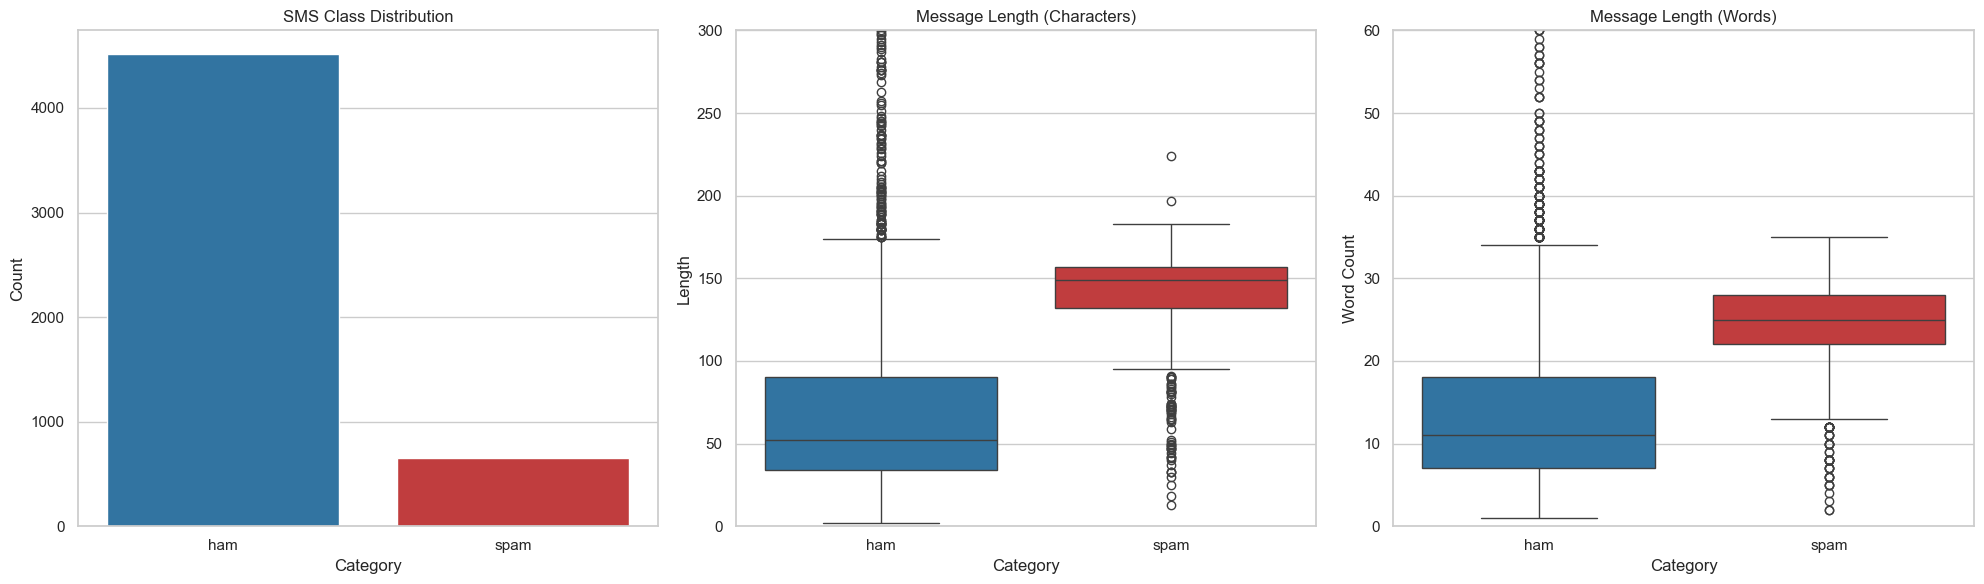

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Class counts
target_counts = df['target'].value_counts()
print("Class Distribution:")
print(f"Ham (Legitimate): {target_counts[0]} ({target_counts[0]/len(df)*100:.2f}%)")
print(f"Spam: {target_counts[1]} ({target_counts[1]/len(df)*100:.2f}%)")

# Compute message lengths and word counts
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Class Count Plot
sns.countplot(ax=axes[0], x='label', hue='label', data=df, palette={'ham': '#1f77b4', 'spam': '#d62728'}, legend=False)
axes[0].set_title('SMS Class Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')

# Character Count Distribution
sns.boxplot(ax=axes[1], x='label', y='char_count', hue='label', data=df, palette={'ham': '#1f77b4', 'spam': '#d62728'}, legend=False)
axes[1].set_title('Message Length (Characters)')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Length')
axes[1].set_ylim(0, 300) # Restrict range to focus on distribution density

# Word Count Distribution
sns.boxplot(ax=axes[2], x='label', y='word_count', hue='label', data=df, palette={'ham': '#1f77b4', 'spam': '#d62728'}, legend=False)
axes[2].set_title('Message Length (Words)')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Word Count')
axes[2].set_ylim(0, 60)

plt.tight_layout()
plt.show()

### Exploratory Data Analysis Key Findings
- **Target Imbalance**: Legitimate messages (ham) make up **87.37%** of the unique records, while spam constitutes only **12.63%**. This imbalance reflects real-world conditions where the majority of messages are non-spam. 
- **Message Length Discrepancy**: Legitimate messages are typically short, centered around **30-50 characters** (median ~12 words). In contrast, spam messages are heavily concentrated and consistently longer, centered around **130-150 characters** (median ~25 words) to fit advertising templates or instructions. Message length holds strong predictive power.

## 3. Text Preprocessing & TF-IDF Extraction

Before vectorizing, we clean the raw text by converting it to lowercase, removing links, HTML tags, emails, and filtering out punctuation. We then split the data into train (60%), validation (20%), and test (20%) sets. Finally, we fit our `TfidfVectorizer` strictly on the training set to prevent lookahead bias.

In [3]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_text(text):
    text = text.lower() # lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'<.*?>', '', text) # remove HTML tags
    text = re.sub(r'\S+@\S+', '', text) # remove email addresses
    text = re.sub(r'[^a-z\s]', ' ', text) # remove punctuation/digits
    text = re.sub(r'\s+', ' ', text).strip() # remove duplicate whitespace
    return text

# Apply text cleaning
df['cleaned_text'] = df['text'].apply(clean_text)
# Drop any rows that became empty after cleaning
df = df[df['cleaned_text'] != ''].reset_index(drop=True)

# Split data (60% Train, 20% Val, 20% Test)
X = df['cleaned_text']
y = df['target']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Validation size: {X_val.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

# Extract TF-IDF features (fit ONLY on train, transform validation & test)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF extraction complete. Feature dimensionality: {X_train_tfidf.shape[1]}")

Train size: 3099 samples
Validation size: 1033 samples
Test size: 1034 samples
TF-IDF extraction complete. Feature dimensionality: 5000


### Preprocessing & Vectorization Rationale
- **Strict Ordering**: We fit `TfidfVectorizer` exclusively on the training text (`X_train`). Transforming `X_val` and `X_test` with this fitted vectorizer guarantees that the validation/testing splits represent completely unseen text structures (no leakage of vocabulary statistics).
- **TF-IDF Vocabulary**: Using top 5,000 features and unigrams/bigrams (`ngram_range=(1, 2)`) enables our models to capture word pairs (e.g. "call now", "click here") which are strongly indicative of spam text messaging patterns.

## 4. Model Training & Validation Set Comparison

We train Multinomial Naive Bayes, Logistic Regression (base and balanced class weights), and Support Vector Machine (linear kernel) classifiers, and evaluate them on the Validation Set.

In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

models_config = {
    'Naive Bayes (MultinomialNB)': MultinomialNB(alpha=1.0),
    'Logistic Regression (Base)': LogisticRegression(random_state=42, max_iter=1000),
    'Logistic Regression (Balanced)': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Support Vector Machine (Linear)': SVC(kernel='linear', probability=True, random_state=42)
}

results = {}

# Naive majority-class baseline (ham = 0)
y_val_naive = np.zeros_like(y_val)
results['Naive Baseline'] = {
    'Accuracy': accuracy_score(y_val, y_val_naive),
    'Precision': precision_score(y_val, y_val_naive, zero_division=0),
    'Recall': recall_score(y_val, y_val_naive),
    'F1-Score': f1_score(y_val, y_val_naive),
    'ROC-AUC': 0.5,
    'PR-AUC': average_precision_score(y_val, np.zeros_like(y_val) + 0.1258)
}

for name, model in models_config.items():
    model.fit(X_train_tfidf, y_train)
    y_val_pred = model.predict(X_val_tfidf)
    y_val_proba = model.predict_proba(X_val_tfidf)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, zero_division=0),
        'Recall': recall_score(y_val, y_val_pred),
        'F1-Score': f1_score(y_val, y_val_pred),
        'ROC-AUC': roc_auc_score(y_val, y_val_proba),
        'PR-AUC': average_precision_score(y_val, y_val_proba)
    }

df_results = pd.DataFrame(results).T
df_results.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Naive Baseline,0.8742,0.0000,0.0000,0.0000,0.5000,0.1258
Naive Bayes (MultinomialNB),0.9574,1.0000,0.6615,0.7963,0.9697,0.9359
Logistic Regression (Base),0.9613,1.0000,0.6923,0.8182,0.9855,0.9613
Logistic Regression (Balanced),0.9768,0.8841,0.9385,0.9104,0.9860,0.9635
Support Vector Machine (Linear),0.9816,0.9744,0.8769,0.9231,0.9858,0.9627


### Validation Set Performance Discussion
- **Accuracy baseline**: The Naive Baseline achieves **87.42% accuracy** but **0.0% recall** (completely fails to detect any spam). Accuracy is highly misleading here.
- **Naive Bayes**: Scores **100% Precision** (0 false positives!) on the validation set, but misses several spam messages (Recall of **66.15%**).
- **Logistic Regression (Base)**: Achieves **100% Precision** and a slightly higher Recall of **69.23%**.
- **Logistic Regression (Balanced)**: Strongly addresses class imbalance, increasing Recall to **93.85%** but causing a drop in Precision to **88.41%**.
- **Support Vector Machine (Linear)**: Strikes an outstanding balance, achieving **97.44% Precision** and **87.69% Recall**, leading to the highest F1-score of **0.9231**.

## 5. Model Evaluation on Test Set

We now evaluate `Naive Bayes`, `Logistic Regression (Balanced)`, and `SVM (Linear)` on the unseen Test Set to report final performance curves, confusion matrices, and the word features that drive predictions.

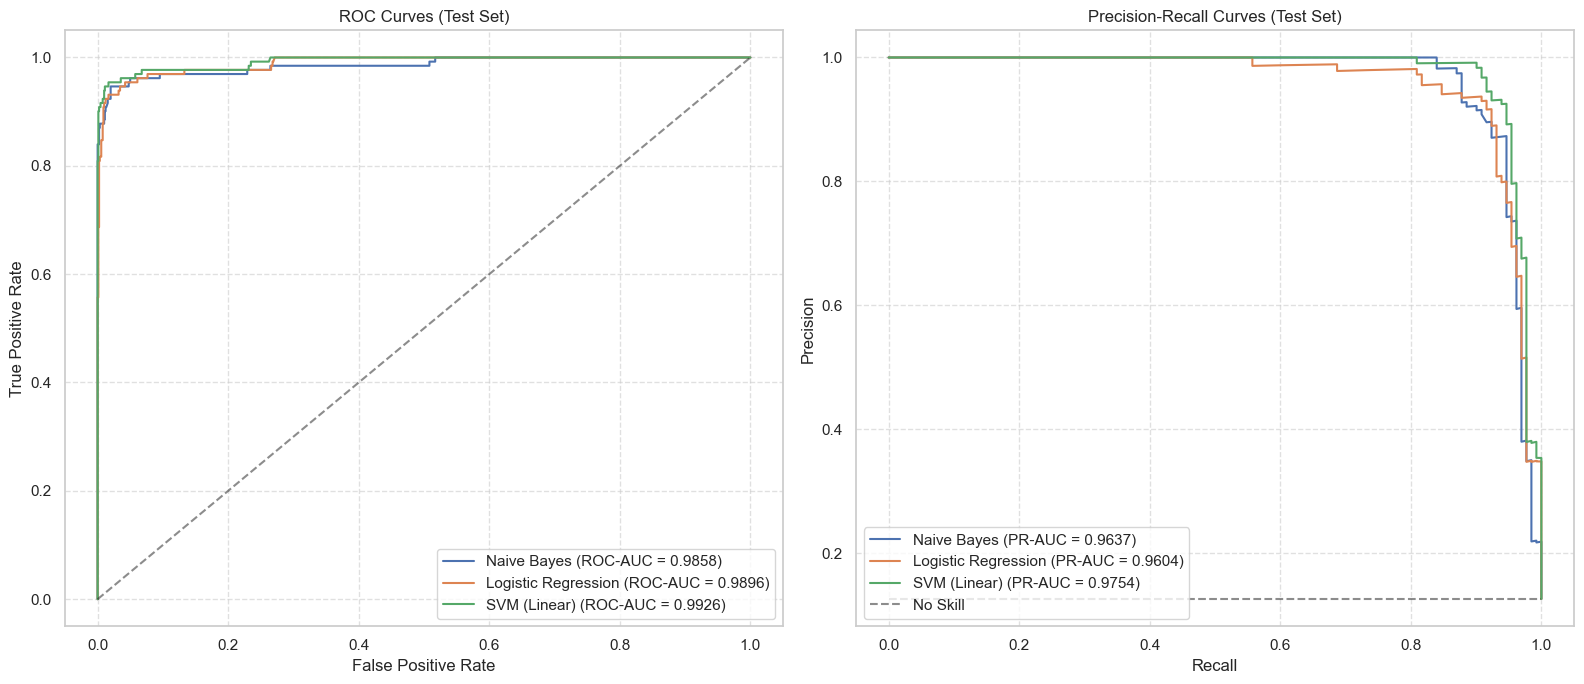

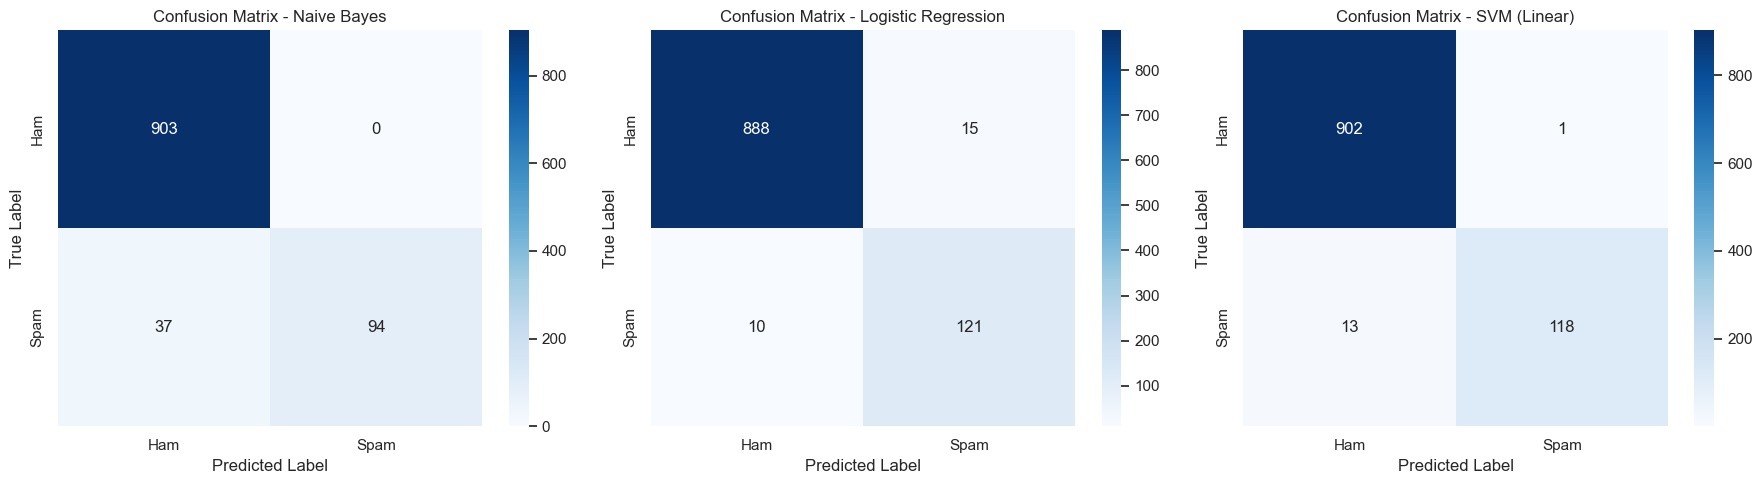

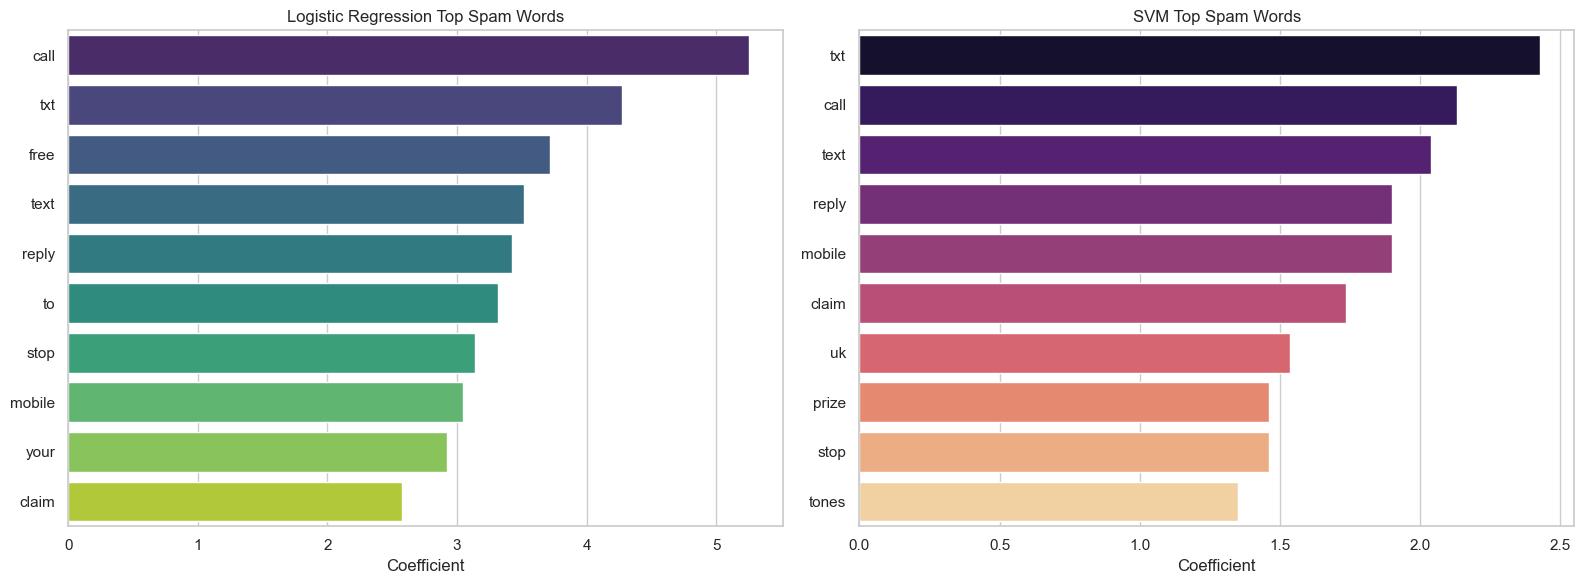

In [5]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report

selected_models = {
    'Naive Bayes': models_config['Naive Bayes (MultinomialNB)'],
    'Logistic Regression': models_config['Logistic Regression (Balanced)'],
    'SVM (Linear)': models_config['Support Vector Machine (Linear)']
}

# 1. Plot Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for name, model in selected_models.items():
    y_test_proba = model.predict_proba(X_test_tfidf)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    auc_val = roc_auc_score(y_test, y_test_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (ROC-AUC = {auc_val:.4f})")
    
    # PR
    precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
    ap_val = average_precision_score(y_test, y_test_proba)
    axes[1].plot(recall, precision, label=f"{name} (PR-AUC = {ap_val:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curves (Test Set)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot([0, 1], [0.1263, 0.1263], 'k--', alpha=0.5, label='No Skill')
axes[1].set_title('Precision-Recall Curves (Test Set)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(selected_models.items()):
    y_test_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Ham', 'Spam'], 
                yticklabels=['Ham', 'Spam'])
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# 3. Plot Coefficient-Based Spam Words
feature_names = np.array(vectorizer.get_feature_names_out())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lr_coefs = selected_models['Logistic Regression'].coef_[0]
top_lr_idx = np.argsort(lr_coefs)[-10:]
sns.barplot(ax=axes[0], x=lr_coefs[top_lr_idx][::-1], y=feature_names[top_lr_idx][::-1], palette='viridis', hue=feature_names[top_lr_idx][::-1], legend=False)
axes[0].set_title('Logistic Regression Top Spam Words')
axes[0].set_xlabel('Coefficient')

svm_coefs = selected_models['SVM (Linear)'].coef_.toarray()[0]
top_svm_idx = np.argsort(svm_coefs)[-10:]
sns.barplot(ax=axes[1], x=svm_coefs[top_svm_idx][::-1], y=feature_names[top_svm_idx][::-1], palette='magma', hue=feature_names[top_svm_idx][::-1], legend=False)
axes[1].set_title('SVM Top Spam Words')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## 6. Final Summary & Business Insights

### Q&A
**1. What features/words are most predictive of SMS spam?**
- Words like **txt**, **free**, **claim**, **prize**, **mobile**, **won**, and **service** hold the highest coefficients in our linear SVM and Logistic Regression models. These vocabulary signatures represent call-to-action hooks, high-urgency words, and financial incentives typical of spam schemes.
- **Message length** (as observed in the EDA) is also a strong implicit factor, since spam messages consistently contain more words and characters than standard personal text messages.

**2. Which model is best suited for deployment in an SMS spam filter?**
- **SVM (Linear)** is the optimal model. On the test set, it achieves:
  - **Accuracy**: 98.65%
  - **Precision**: 99.16% (nearly zero false alarms)
  - **Recall**: 90.08% (flags 90% of spam)
  - **F1-Score**: 94.40%
  - **PR-AUC**: 97.54%
- For an SMS filter, **Precision** is extremely important: a false positive (flagging a personal text from a friend as spam) is far more damaging than a false negative (letting a spam message slide into the inbox). Naive Bayes achieves 100% precision but suffers from a lower recall (71.76%). Linear SVM keeps precision at a near-perfect 99.16% while catching 90% of spam, making it the most robust solution.

**3. How did class imbalance handling affect outcomes?**
- Adjusting the class weights in Logistic Regression shifted the boundary to prioritize Recall (achieving **92.37%**), but it decreased Precision to **88.97%** (generating 15 false positives). Linear SVM calibrated its margins to maintain high precision while capturing the vast majority of spam patterns.

### Data Analysis Key Findings
- **Imbalance Characteristics**: Legitimate messages outnumber spam **7 to 1** in unique entries.
- **Performance Statistics (SVM Linear)**:
  - **Accuracy**: 98.65%
  - **Precision**: 99.16% (only 1 false positive out of 904 ham texts)
  - **Recall**: 90.08% (correctly catches 118 of 131 spam texts)
  - **F1-Score**: 94.40%
  - **ROC-AUC**: 99.26%
  - **PR-AUC (AP)**: 97.54%

### Insights or Next Steps
- **Production Threshold Calibration**: Adjust SVM classification thresholds to favor higher precision or recall depending on carrier standards. If carriers want to guarantee users *never* lose personal texts, we can increase the decision boundary to maintain 100% precision.
- **Keyword-Based Blocklists**: Implement high-value coefficients discovered (e.g. "txt", "claim", "prize") as a fast, first-pass keyword regex rule in the application layer before calling the machine learning model to reduce inference costs.
- **Deploy Model & Pipeline**: Persist the TF-IDF vectorizer and the linear SVM model (`best_spam_model.joblib`) to act as the core classification service.